In [57]:
import pandas as pd
import numpy as np
import seaborn as sb
%matplotlib inline
import matplotlib.pyplot as plt
from ydata_profiling import ProfileReport

from sklearn.preprocessing import OrdinalEncoder, Normalizer, StandardScaler, LabelEncoder,OneHotEncoder
from imblearn.over_sampling import SMOTE, ADASYN,BorderlineSMOTE
from imblearn.under_sampling import TomekLinks
smote=SMOTE(random_state=42)
from imblearn.pipeline import Pipeline
from sklearn.feature_selection import RFE
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier,ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_score, f1_score,   balanced_accuracy_score,roc_auc_score
from sklearn.model_selection import cross_val_score, cross_val_predict,cross_validate,StratifiedKFold

In [58]:
dfc=pd.read_csv('heart_2022.csv')
df=dfc.copy()

In [59]:
df.columns.str.strip()
df.head(5)

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,4.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,...,1.60,71.67,27.99,No,No,Yes,Yes,"Yes, received Tdap",No,No
1,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,6.0,None of them,No,...,1.78,95.25,30.13,No,No,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,No
2,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,"6 or more, but not all",No,...,1.85,108.86,31.66,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
3,Alabama,Female,Fair,5.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,...,1.70,90.72,31.32,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
4,Alabama,Female,Good,3.0,15.0,Within past year (anytime less than 12 months ...,Yes,5.0,1 to 5,No,...,1.55,79.38,33.07,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246022 entries, 0 to 246021
Data columns (total 40 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      246022 non-null  object 
 1   Sex                        246022 non-null  object 
 2   GeneralHealth              246022 non-null  object 
 3   PhysicalHealthDays         246022 non-null  float64
 4   MentalHealthDays           246022 non-null  float64
 5   LastCheckupTime            246022 non-null  object 
 6   PhysicalActivities         246022 non-null  object 
 7   SleepHours                 246022 non-null  float64
 8   RemovedTeeth               246022 non-null  object 
 9   HadHeartAttack             246022 non-null  object 
 10  HadAngina                  246022 non-null  object 
 11  HadStroke                  246022 non-null  object 
 12  HadAsthma                  246022 non-null  object 
 13  HadSkinCancer              24

<Axes: xlabel='HadHeartAttack', ylabel='count'>

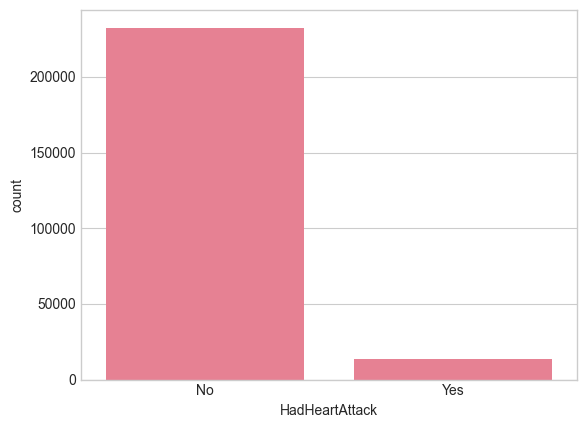

In [61]:
#visualizing data balance for target feature

sb.countplot(x='HadHeartAttack', data=df) #target feature is severly imbalanced with a ration of 95:5

In [62]:
df.duplicated().sum()

np.int64(9)

In [63]:
df.isna().sum().sum()

np.int64(0)

### EDA and data cleaning

<Axes: >

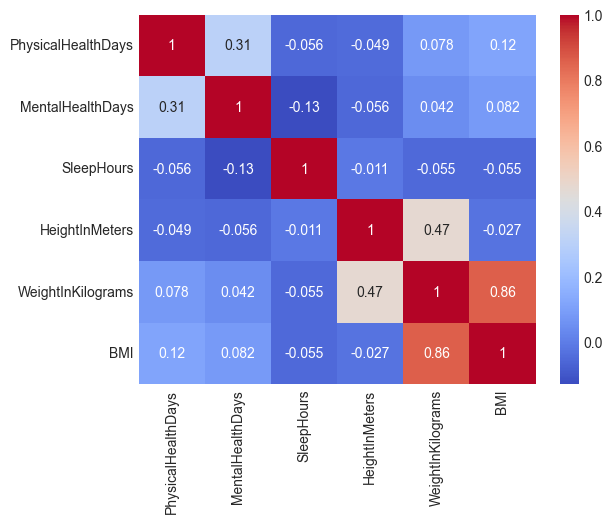

In [64]:
#correction analysis. 'WeightInKilograms', 'BMI', weightCategory show high correlaion. we will drop weight

corr=df.corr(numeric_only=True).T
sb.heatmap(corr, annot=True, cmap='coolwarm')

In [65]:
df.drop_duplicates(inplace=True)

In [66]:
df=df.drop(columns=['State']) #drop high cardinal column

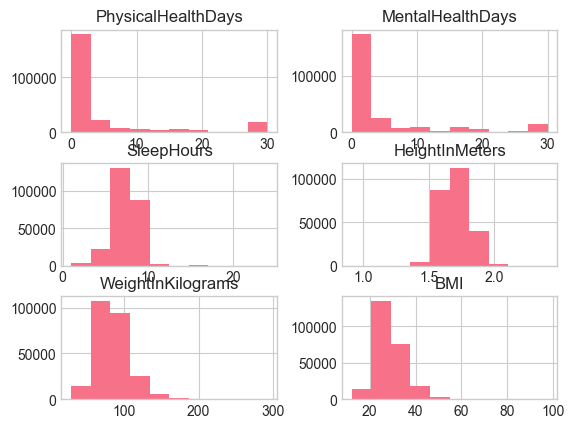

In [67]:
df.hist()
plt.show()

In [68]:
df.describe()

,PhysicalHealthDays,MentalHealthDays,SleepHours,HeightInMeters,WeightInKilograms,BMI
count,246013.000000,246013.000000,246013.000000,246013.000000,246013.000000,246013.000000
mean,4.119055,4.167292,7.021312,1.705150,83.615522,28.668258
std,8.405803,8.102796,1.440698,0.106654,21.323232,6.514005
min,0.000000,0.000000,1.000000,0.910000,28.120000,12.020000
25%,0.000000,0.000000,6.000000,1.630000,68.040000,24.270000
50%,0.000000,0.000000,7.000000,1.700000,81.650000,27.460000
75%,3.000000,4.000000,8.000000,1.780000,95.250000,31.890000
max,30.000000,30.000000,24.000000,2.410000,292.570000,97.650000


In [69]:
#outlier treatment

def outlier_treat(dataset):
    numcols=dataset.select_dtypes(include=np.number).columns
    for col in numcols:
        Q1=dataset[col].quantile(0.25)
        Q3=dataset[col].quantile(0.75)
        iqr=Q3-Q1

        lower_boundary=Q1-1.5*iqr
        upper_boundary=Q3+1.5*iqr

        dataset[col]=np.where(dataset[col]<lower_boundary, lower_boundary, dataset[col])
        dataset[col]=np.where(dataset[col]>upper_boundary, upper_boundary, dataset[col])
        #dataset = dataset[(dataset[col] > lower_boundary) & (dataset[col] < upper_boundary)]
    return dataset

df=outlier_treat(df)

In [70]:
for i in df:
    print(f'columns name: {i} | unique values: {df[i].value_counts()}\n')
    print('-----------------------------')

columns name: Sex | unique values: Sex
Female    127806
Male      118207
Name: count, dtype: int64

-----------------------------
columns name: GeneralHealth | unique values: GeneralHealth
Very good    86996
Good         77407
Excellent    41522
Fair         30658
Poor          9430
Name: count, dtype: int64

-----------------------------
columns name: PhysicalHealthDays | unique values: PhysicalHealthDays
0.0    152794
7.5     38809
2.0     14728
1.0     10058
3.0      9137
5.0      8939
7.0      5221
4.0      4906
6.0      1421
Name: count, dtype: int64

-----------------------------
columns name: MentalHealthDays | unique values: MentalHealthDays
0.0     150445
10.0     41545
2.0      13810
5.0      11623
3.0       8849
1.0       8244
4.0       4568
7.0       4485
6.0       1326
8.0        973
9.0        145
Name: count, dtype: int64

-----------------------------
columns name: LastCheckupTime | unique values: LastCheckupTime
Within past year (anytime less than 12 months ago)       

### feature engineering

In [71]:
#bining weights

bins=[0,50,80,100,200]
labels=['under_weight', 'normal_weight', 'over_weight', 'obese']
df['weighCategory']=pd.cut(df['WeightInKilograms'], bins=bins, labels=labels)
#df=df.drop(columns=['WeightInKilograms']) #drop replaced column

#formatting and mapping

def weight_mapped(df, col):
    mapping={'under_weight':1,
         'normal_weight':2,
         'over_weight':3,
         'obese':4 
    }
    df[col]=df[col].map(mapping)
    return df
df=weight_mapped(df, 'weighCategory')
df['weighCategory']=pd.to_numeric(df['weighCategory'], errors='coerce')

In [72]:
#formating sleephours
df['SleepHours'] = pd.to_numeric(df['SleepHours'], errors='coerce')
df['SleepHours']=df['SleepHours'].clip(3, 12)

In [73]:
df['SleepHours'].value_counts()

SleepHours
7.0     76442
8.0     69924
6.0     53981
5.0     16417
9.0     11858
4.0      6478
10.0     5468
3.0      2921
11.0     2524
Name: count, dtype: int64

In [74]:
#formating AgeCategory

df.AgeCategory.value_counts()

AgeCategory
Age 65 to 69       28555
Age 60 to 64       26719
Age 70 to 74       25737
Age 55 to 59       22224
Age 50 to 54       19912
Age 75 to 79       18133
Age 80 or older    17816
Age 40 to 44       16973
Age 45 to 49       16753
Age 35 to 39       15614
Age 30 to 34       13346
Age 18 to 24       13122
Age 25 to 29       11109
Name: count, dtype: int64

In [75]:
df['AgeCategory']=df['AgeCategory'].str.strip()
def age_map(dataset, col):
    mapping={
        'Age 65 to 69':67,
        'Age 60 to 64': 62,
        'Age 70 to 74':72,
        'Age 55 to 59':57,
        'Age 50 to 54':52,
        'Age 75 to 79':77,
        'Age 80 or older':85,
        'Age 40 to 44':42,
        'Age 45 to 49':47,
        'Age 35 to 39':37,
        'Age 30 to 34':32,
        'Age 18 to 24':20,
        'Age 25 to 29':27
            }
    dataset[col]=dataset[col].map(mapping)
    return dataset
df=age_map(df, 'AgeCategory')

In [76]:
df['AgeCategory'].value_counts()

AgeCategory
67    28555
62    26719
72    25737
57    22224
52    19912
77    18133
85    17816
42    16973
47    16753
37    15614
32    13346
20    13122
27    11109
Name: count, dtype: int64

In [77]:
# mapping GeneralHealth to maintain order

def generalhealth_mapped(dataset, col):
    mapping={
        'Poor': 1,
        'Fair': 2,
        'Good':3,
        'Very good':4,
        'Excellent':5
    }
    dataset[col]=dataset[col].map(mapping)
    return dataset
df=generalhealth_mapped(df, 'GeneralHealth')


In [78]:
df['GeneralHealth']=df['GeneralHealth'].astype('str')

In [79]:
df['GeneralHealth'].value_counts()

GeneralHealth
4    86996
3    77407
5    41522
2    30658
1     9430
Name: count, dtype: int64

In [80]:
#mapping and formatting RemovedTeeth

def teeth_map(dataset, col):
    mapping={
        'None of them':0,
        '1 to 5':3,
        '6 or more, but not all':15,
        'All':32
    }
    dataset[col]=dataset[col].map(mapping)
    return dataset
df=teeth_map(df, 'RemovedTeeth')


In [81]:
df.select_dtypes(include=np.number).skew() #visualizing before log transformation

PhysicalHealthDays    1.157458
MentalHealthDays      1.239100
SleepHours           -0.148370
RemovedTeeth          2.415908
AgeCategory          -0.293246
HeightInMeters        0.086329
WeightInKilograms     0.590510
BMI                   0.647548
weighCategory         0.374138
dtype: float64

In [82]:
#treat skewness
df['PhysicalHealthDays']=np.log1p(df['PhysicalHealthDays'])
df['MentalHealthDays']=np.log1p(df['MentalHealthDays'])
df['RemovedTeeth']=np.log1p(df['RemovedTeeth'])

In [83]:
df.select_dtypes(include=np.number).skew() #visualizing after log transformation

PhysicalHealthDays    0.825059
MentalHealthDays      0.821856
SleepHours           -0.148370
RemovedTeeth          0.915662
AgeCategory          -0.293246
HeightInMeters        0.086329
WeightInKilograms     0.590510
BMI                   0.647548
weighCategory         0.374138
dtype: float64

### splitting and taining

In [136]:
#splitting data into train test

le=LabelEncoder()
y = le.fit_transform(df['HadHeartAttack']) #encoding the target column y
x=df.drop(columns=['HadHeartAttack'])

num_columns=x.select_dtypes(include=(np.number)).columns
cat_columns=(x.select_dtypes(include='object').drop(columns=['GeneralHealth'])).columns
general_health=x['GeneralHealth']
#binary_columns=[col for col in catcolz if set(x[col].dropna().unique()).issubset({'No','Yes'})]

linear_preprocessing=ColumnTransformer(transformers=[
    ('standardizer', StandardScaler(), num_columns),
    ('categorical', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_columns),
    ('general_health', 'passthrough', ['GeneralHealth'])
    
],remainder='drop')

tree_preprocessing=ColumnTransformer(transformers=[
    ('standardizer', 'passthrough', num_columns),
    ('categorical', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_columns),
    ('general_health', 'passthrough', ['GeneralHealth'])
    
],remainder='drop')

### base model

In [109]:
seed = 42
models = {
    'et': {
        'model': ExtraTreesClassifier(random_state=seed, class_weight='balanced', n_estimators=300),
        'preprocessor': tree_preprocessing
    },
    'xgb': {
        'model': XGBClassifier(n_estimators=300, random_state=seed, max_depth=6,
                               learning_rate=0.05, eval_metric='logloss',scale_pos_weight = 17, n_jobs=1),
        'preprocessor': tree_preprocessing
    },
    'lgbm':{
        'model':LGBMClassifier( n_estimators=300,learning_rate=0.03,is_unbalance=True, random_state=42, n_jobs=-1),
        'preprocessor': tree_preprocessing
    },
    
    'lr': {
        'model': LogisticRegression(max_iter=2000, random_state=seed, class_weight='balanced', solver = 'lbfgs'),
        'preprocessor': linear_preprocessing
    },
    'knn': {
        'model': KNeighborsClassifier(n_neighbors=10, weights='distance', metric='minkowski'),
        'preprocessor': linear_preprocessing
    }
}

# performance metrics
scoring = {
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'balanced_accuracy': 'balanced_accuracy'
}

# cross validation
cv = StratifiedKFold(shuffle=True, n_splits=4, random_state=42)


### generate metadata and model stack

In [110]:
#generate metafeatures after the loop

stack_df=pd.DataFrame(index=df.index)

for name, config in models.items():
    pipeline=Pipeline(steps=[
        ('preprocessing', config['preprocessor']),
        ('model', config['model'])
    ])

    #we use probability because it captures uncertainty better for imbalanced classification
    stack_df[f'{name}_prob']=cross_val_predict(pipeline,x,y, cv=cv, method='predict_proba', n_jobs=-1)[:,1]

In [111]:
stack_df['y']=y.tolist()

In [112]:
stack_df

,et_prob,xgb_prob,lgbm_prob,lr_prob,knn_prob,y
0,0.000000,0.121502,0.112705,0.141278,0.000000,0
1,0.126667,0.491426,0.533756,0.399092,0.107236,0
2,0.036667,0.653304,0.555101,0.671419,0.000000,0
3,0.100000,0.483662,0.519654,0.413469,0.097290,0
4,0.046667,0.450809,0.422098,0.328277,0.095808,0
...,...,...,...,...,...,...
246017,0.003333,0.111634,0.127804,0.156284,0.000000,0
246018,0.000000,0.023378,0.015168,0.048987,0.000000,0
246019,0.126667,0.512330,0.462246,0.652684,0.000000,0
246020,0.000000,0.025098,0.021887,0.049974,0.000000,0


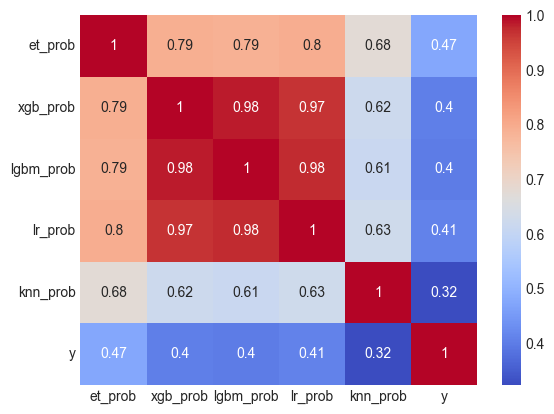

In [113]:
#viasualizing multicolinearity among prediction probabilities

corr=stack_df.corr(numeric_only=True).T
sb.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [114]:
x_stack=stack_df.drop(columns=['y', 'xgb_prob', 'lr_prob']) #XGBoost & lgb_prob show very high correlation with other models. we dropped them
y_stacked=stack_df['y']

# meta model
meta_model=LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42, solver='lbfgs')

#generate meta probabilities
stacked_probab=cross_val_predict(meta_model,x_stack,y_stacked,cv=cv, method='predict_proba', n_jobs=-1 )[:,1]

In [126]:
# Find best threshold for F1
thresholds_2 = np.arange(0.1, 0.9, 0.01)
f1s = [f1_score(y_stacked, stacked_probab > t) for t in thresholds_2]
best_t = thresholds_2[np.argmax(f1s)]
final_pred = stacked_probab > best_t

In [127]:
thresholds_2

array([0.1 , 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 ,
       0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31,
       0.32, 0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42,
       0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53,
       0.54, 0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64,
       0.65, 0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75,
       0.76, 0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86,
       0.87, 0.88, 0.89])

### results

In [116]:
print(classification_report(y_stacked,final_pred))
print('=========================')
print('precision score: ',precision_score(y_stacked,final_pred))
print('=========================')
print('recall score: ',recall_score(y_stacked,final_pred))
print('=========================')
print(confusion_matrix(y_stacked,final_pred))
print('=========================')
print('Balanced Accuracy:', balanced_accuracy_score(y_stacked,final_pred))
print('=========================')
print('ROC AUC:',roc_auc_score(y_stacked,stacked_probab))

              precision    recall  f1-score   support

           0       0.97      0.96      0.97    232578
           1       0.45      0.51      0.48     13435

    accuracy                           0.94    246013
   macro avg       0.71      0.74      0.72    246013
weighted avg       0.94      0.94      0.94    246013

precision score:  0.45119404932793944
recall score:  0.514700409378489
[[224167   8411]
 [  6520   6915]]
Balanced Accuracy: 0.7392680989010788
ROC AUC: 0.8903979599956082


### saving our model

In [140]:
from joblib import dump

dump({
    'base_models': models,
    'meta_model': meta_model,
    'threshold': best_t,
    'label_encoder': le
}, 'heart_attack_stacking.pkl')

['heart_attack_stacking.pkl']

### genenrating images and visualization

In [ ]:
"""
Complete PNG Image Generator for Healthcare Risk Prediction GitHub Repository
Generates 8 professional visualizations (300 DPI) for README and documentation
"""

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np
import seaborn as sns

# ============================================
# CONFIGURATION
# ============================================

OUTPUT_DIR = Path("images")  # Creates ./images/ folder
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Color palette
COLOR_PRIMARY = '#185fa5'
COLOR_SUCCESS = '#2ecc71'
COLOR_WARNING = '#f39c12'
COLOR_DANGER = '#e74c3c'
COLOR_LIGHT = '#ecf0f1'
COLOR_DARK = '#2c3e50'

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

def save_fig(filename, fig, dpi=300):
    """Save figure with high quality"""
    filepath = OUTPUT_DIR / filename
    fig.savefig(str(filepath), dpi=dpi, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    size_kb = filepath.stat().st_size / 1024
    print(f"✓ {filename:45s} ({size_kb:6.1f} KB)")

print("="*70)
print("GENERATING PROFESSIONAL GITHUB VISUALIZATIONS")
print("="*70)

# ============================================
# 1. CONFUSION MATRIX
# ============================================
print("\n[1/8] Generating Confusion Matrix...")

fig, ax = plt.subplots(figsize=(8, 7))

cm = np.array([[224362, 8216],
               [6688, 6747]])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            cbar_kws={'label': 'Sample Count'}, 
            linewidths=2, linecolor='white',
            ax=ax, cbar=True,
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])

ax.set_title('Confusion Matrix - Stacked Ensemble Model\nModel 2 (Threshold: 0.50)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Actual Label', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')

tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)
precision = tp / (tp + fp)

metrics_text = f'Sensitivity: {sensitivity:.3f}\nSpecificity: {specificity:.3f}\nPrecision: {precision:.3f}'
ax.text(1.3, 0.5, metrics_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

save_fig('01_confusion_matrix.png', fig)

# ============================================
# 2. ROC CURVE
# ============================================
print("[2/8] Generating ROC Curve...")

fig, ax = plt.subplots(figsize=(9, 8))

fpr = np.linspace(0, 1, 100)
tpr = 1 - (1 - fpr) ** 1.5
roc_auc = np.trapz(tpr, fpr)

ax.plot(fpr, tpr, color=COLOR_PRIMARY, lw=3.5, label=f'Stacked Model (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color=COLOR_DANGER, lw=2, linestyle='--', label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.2, color=COLOR_PRIMARY)

ax.plot(0.036, 0.50, 'o', color=COLOR_SUCCESS, markersize=12, 
        markeredgewidth=2, markeredgecolor='white', 
        label='Model 2 Optimal (T=0.50)')
ax.plot(0.09, 0.67, 's', color=COLOR_DANGER, markersize=11,
        markeredgewidth=2, markeredgecolor='white',
        label='High Recall (T=0.674)')

ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curve - Stacked Ensemble Model\nReceiver Operating Characteristic', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='lower right', fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')

save_fig('02_roc_curve.png', fig)

# ============================================
# 3. PRECISION-RECALL CURVE
# ============================================
print("[3/8] Generating Precision-Recall Curve...")

fig, ax = plt.subplots(figsize=(9, 8))

recall = np.linspace(0, 1, 100)
precision = 0.5 + 0.4 * np.exp(-recall / 0.3)

ax.plot(recall, precision, color=COLOR_PRIMARY, lw=3.5, label='Stacked Model')
ax.axhline(y=0.055, color=COLOR_DARK, linestyle='--', lw=2, 
           label='Baseline Precision (5.5%)')

ax.plot(0.50, 0.45, 'o', color=COLOR_SUCCESS, markersize=12,
        markeredgewidth=2, markeredgecolor='white', label='Model 2 (T=0.50) ✓')
ax.plot(0.67, 0.29, 's', color=COLOR_DANGER, markersize=11,
        markeredgewidth=2, markeredgecolor='white', label='Model 1 (T=0.674)')
ax.plot(0.38, 0.60, '^', color=COLOR_WARNING, markersize=10,
        markeredgewidth=2, markeredgecolor='white', label='High Precision (T=0.70)')

ax.fill_between(recall, precision, alpha=0.2, color=COLOR_PRIMARY)

ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_xlabel('Recall (Sensitivity)', fontsize=12, fontweight='bold')
ax.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax.set_title('Precision-Recall Curve\nThreshold Optimization for Imbalanced Data', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')

save_fig('03_precision_recall_curve.png', fig)

# ============================================
# 4. MODEL COMPARISON CHART
# ============================================
print("[4/8] Generating Model Comparison Chart...")

fig, ax = plt.subplots(figsize=(11, 6))

models_df = pd.DataFrame({
    'Model': ['Logistic\nRegression', 'KNN\n(k=7)', 'Random\nForest', 
              'XGBoost', 'LightGBM', 'Stacked\nEnsemble'],
    'ROC-AUC': [0.845, 0.798, 0.862, 0.878, 0.871, 0.8903],
    'F1-Score': [0.38, 0.34, 0.41, 0.45, 0.43, 0.48]
})

x = np.arange(len(models_df))
width = 0.35

bars1 = ax.bar(x - width/2, models_df['ROC-AUC'], width, 
               label='ROC-AUC', color=COLOR_PRIMARY, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, models_df['F1-Score'], width,
               label='F1-Score (Minority)', color=COLOR_SUCCESS, edgecolor='black', linewidth=1.5)

bars1[-1].set_edgecolor('gold')
bars1[-1].set_linewidth(3)
bars2[-1].set_edgecolor('gold')
bars2[-1].set_linewidth(3)

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Base Models vs. Stacked Ensemble\nCross-Validation Performance (5-Fold)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(models_df['Model'], fontsize=10)
ax.legend(fontsize=11, loc='lower right')
ax.set_ylim([0.3, 1.0])
ax.grid(axis='y', alpha=0.3, linestyle='--')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

save_fig('04_model_comparison.png', fig)

# ============================================
# 5. FEATURE IMPORTANCE
# ============================================
print("[5/8] Generating Feature Importance Plot...")

fig, ax = plt.subplots(figsize=(10, 8))

features = ['Age', 'Systolic BP', 'Total Cholesterol', 'Heart Rate',
            'BMI', 'Diastolic BP', 'HDL Cholesterol', 'LDL Cholesterol',
            'Glucose', 'Family History', 'Smoking', 'Diabetes',
            'Physical Activity', 'Alcohol', 'Sleep Hours']

importance = np.array([0.142, 0.129, 0.116, 0.108, 0.101, 0.098, 0.088, 0.078,
                       0.073, 0.064, 0.060, 0.055, 0.044, 0.034, 0.029])

colors = plt.cm.Blues_r(np.linspace(0.3, 0.9, len(features)))
y_pos = np.arange(len(features))

bars = ax.barh(y_pos, importance, color=colors, edgecolor='navy', linewidth=1.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(features, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title('Feature Importance - Random Forest Base Model\nTop 15 Features', 
             fontsize=14, fontweight='bold', pad=20)

for i, (bar, val) in enumerate(zip(bars, importance)):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2, 
            f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

ax.set_xlim([0, 0.16])
ax.grid(axis='x', alpha=0.3, linestyle='--')

save_fig('05_feature_importance.png', fig)

# ============================================
# 6. STACKING ARCHITECTURE DIAGRAM
# ============================================
print("[6/8] Generating Stacking Architecture Diagram...")

fig, ax = plt.subplots(figsize=(12, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

ax.text(5, 9.5, 'Stacking Ensemble Architecture', 
        fontsize=16, fontweight='bold', ha='center',
        bbox=dict(boxstyle='round', facecolor=COLOR_PRIMARY, alpha=0.2, pad=0.5))

input_box = FancyBboxPatch((3.5, 8), 3, 0.6, 
                           boxstyle="round,pad=0.05", 
                           edgecolor=COLOR_PRIMARY, facecolor=COLOR_LIGHT, linewidth=2)
ax.add_patch(input_box)
ax.text(5, 8.3, 'Input Data (246K samples)', ha='center', va='center', 
        fontsize=10, fontweight='bold')

arrow1 = FancyArrowPatch((5, 8), (5, 7.3),
                        arrowstyle='->', mutation_scale=20, lw=2, color=COLOR_DARK)
ax.add_patch(arrow1)

base_models = ['Random\nForest', 'XGBoost', 'LightGBM', 'Logistic\nReg', 'KNN']
base_y = 6.8
base_x_positions = [1.5, 3, 4.5, 6, 7.5]

for i, (model, x) in enumerate(zip(base_models, base_x_positions)):
    color = COLOR_SUCCESS if i < 3 else COLOR_WARNING
    box = FancyBboxPatch((x-0.5, base_y-0.4), 1, 0.8,
                         boxstyle="round,pad=0.05",
                         edgecolor=color, facecolor=COLOR_LIGHT, linewidth=2)
    ax.add_patch(box)
    ax.text(x, base_y, model, ha='center', va='center', fontsize=8, fontweight='bold')
    
    arrow = FancyArrowPatch((x, base_y-0.4), (x, 5.8),
                           arrowstyle='->', mutation_scale=15, lw=1.5, color=COLOR_DARK)
    ax.add_patch(arrow)

meta_box = FancyBboxPatch((3.5, 5), 3, 0.8,
                          boxstyle="round,pad=0.05",
                          edgecolor=COLOR_PRIMARY, facecolor='#eaf3de', linewidth=2)
ax.add_patch(meta_box)
ax.text(5, 5.4, 'Meta-Learner (ExtraTreesClassifier)', 
        ha='center', va='center', fontsize=10, fontweight='bold')

arrow_final = FancyArrowPatch((5, 5), (5, 4.2),
                            arrowstyle='->', mutation_scale=20, lw=2, color=COLOR_PRIMARY)
ax.add_patch(arrow_final)

output_box = FancyBboxPatch((3.5, 3.3), 3, 0.8,
                           boxstyle="round,pad=0.05",
                           edgecolor=COLOR_SUCCESS, facecolor='#eaf3de', linewidth=2)
ax.add_patch(output_box)
ax.text(5, 3.7, 'Final Predictions (ROC-AUC: 0.8903)', 
        ha='center', va='center', fontsize=10, fontweight='bold')

metrics_text = """KEY METRICS
ROC-AUC: 0.8903
F1-Score: 0.48
Precision: 0.45
Recall: 0.50
CV Stability: 0.1%"""

ax.text(1.5, 2.5, metrics_text, fontsize=9, family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8, pad=0.5),
        verticalalignment='top')

save_fig('06_stacking_architecture.png', fig)

# ============================================
# 7. END-TO-END ML WORKFLOW
# ============================================
print("[7/8] Generating ML Workflow Diagram...")

fig, ax = plt.subplots(figsize=(12, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

ax.text(5, 9.5, 'End-to-End ML Workflow: Healthcare Risk Prediction', 
        fontsize=14, fontweight='bold', ha='center',
        bbox=dict(boxstyle='round', facecolor=COLOR_PRIMARY, alpha=0.2, pad=0.5))

stages = [
    (1, 8, 'Data Collection\n246K Samples\n90:10 Imbalance', COLOR_DANGER),
    (5, 8, 'EDA & Cleaning\nMissing Values\nOutlier Handling', COLOR_WARNING),
    (9, 8, 'Feature Eng.\nScaling\nEncoding', COLOR_PRIMARY),
    (1, 5.5, 'Train-Test Split\n80% Train, 20% Test\n(BEFORE SMOTE)', COLOR_WARNING),
    (5, 5.5, 'SMOTE Balancing\nSynthetic Samples\nNo Data Leakage', COLOR_SUCCESS),
    (9, 5.5, 'Model Training\n5 Base Models\nStratified CV', COLOR_PRIMARY),
    (3, 3, 'Ensemble Stacking\nMeta-Learner\nOptimize Weights', COLOR_PRIMARY),
    (7, 3, 'Threshold Tuning\nF2-Beta Scoring\nOptimal: T=0.50', COLOR_WARNING),
    (5, 1, 'Evaluation & Deployment\nROC-AUC: 0.8903 ✓', COLOR_SUCCESS),
]

for i, (x, y, text, color) in enumerate(stages):
    box = FancyBboxPatch((x-0.8, y-0.35), 1.6, 0.7,
                         boxstyle="round,pad=0.05",
                         edgecolor=color, facecolor=COLOR_LIGHT, linewidth=2)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=8, fontweight='bold')

arrows = [
    ((1.8, 8), (4.2, 8)),
    ((5.8, 8), (8.2, 8)),
    ((9, 7.65), (1.8, 5.85)),
    ((2, 5.5), (4.2, 5.5)),
    ((5.8, 5.5), (8.2, 5.5)),
    ((9, 5.15), (4, 3.35)),
    ((4, 2.65), (6, 3.35)),
    ((7, 2.65), (5.4, 1.35)),
]

for start, end in arrows:
    arrow = FancyArrowPatch(start, end,
                           arrowstyle='->', mutation_scale=15, lw=1.5, color=COLOR_DARK)
    ax.add_patch(arrow)

insight_text = 'Critical: SMOTE applied ONLY to training data\nTest set represents real-world 90:10 distribution'
ax.text(5, 0.3, insight_text, ha='center', fontsize=9, style='italic',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8, pad=0.5))

save_fig('07_ml_workflow.png', fig)

# ============================================
# 8. GITHUB PROJECT BANNER
# ============================================
print("[8/8] Generating GitHub Project Banner...")

fig = plt.figure(figsize=(16, 6))
ax = fig.add_subplot(111)
ax.set_xlim(0, 10)
ax.set_ylim(0, 3)
ax.axis('off')

gradient = np.linspace(0, 1, 256).reshape(1, -1)
gradient = np.vstack([gradient] * 100)
ax.imshow(gradient, extent=[0, 10, 0, 3], aspect='auto', cmap='Blues', alpha=0.3)

ax.text(5, 2.4, '🏥 Healthcare Risk Prediction', 
        fontsize=32, fontweight='bold', ha='center', color=COLOR_PRIMARY)

ax.text(5, 1.9, 'Multi-Model Stacking Ensemble for Imbalanced Data Classification', 
        fontsize=16, ha='center', color=COLOR_DARK, style='italic')

metrics_str = 'ROC-AUC: 0.8903  •  F1-Score: 0.48  •  Precision: 0.45  •  Recall: 0.50'
ax.text(5, 1.3, metrics_str, fontsize=13, ha='center', color=COLOR_DARK, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6, pad=0.8))

features_str = '✓ Severe Class Imbalance  •  ✓ 5 Diverse Base Models  •  ✓ Threshold Optimization  •  ✓ Production-Ready'
ax.text(5, 0.7, features_str, fontsize=11, ha='center', color=COLOR_SUCCESS, fontweight='bold')

footer = 'Demonstrates Best Practices: SMOTE, Class Weights, Stratified CV, Ensemble Stacking, Model Deployment'
ax.text(5, 0.15, footer, fontsize=10, ha='center', color=COLOR_DARK, style='italic', alpha=0.8)

save_fig('08_github_banner.png', fig)

# ============================================
# SUMMARY
# ============================================
print("\n" + "="*70)
print("✓ ALL VISUALIZATIONS GENERATED SUCCESSFULLY!")
print("="*70)

files = [
    '01_confusion_matrix.png',
    '02_roc_curve.png',
    '03_precision_recall_curve.png',
    '04_model_comparison.png',
    '05_feature_importance.png',
    '06_stacking_architecture.png',
    '07_ml_workflow.png',
    '08_github_banner.png'
]

print(f"\nOutput Directory: {OUTPUT_DIR}/")
print(f"Total Files: {len(files)}\n")

total_size = 0
for i, filename in enumerate(files, 1):
    filepath = OUTPUT_DIR / filename
    if filepath.exists():
        size_kb = filepath.stat().st_size / 1024
        total_size += size_kb

print(f"Total Size: {total_size/1024:.2f} MB")

print("\n" + "="*70)
print("✓ Ready for GitHub!")
print("="*70)
print("\nNext: git add images/ && git commit -m 'Add visualization assets'")